In [6]:
# import libraries
import pandas as pd

In [7]:
# Load datasets
d1 = pd.read_csv('student-mat.csv', sep=';')   # Math dataset
d2 = pd.read_csv('student-por.csv', sep=';')   # Portuguese dataset

In [8]:
# Add subject column
d1['subject'] = 'Math'
d2['subject'] = 'Portuguese'

In [9]:
# Show before merge
print("D1 (Math):")
print(d1[['age','studytime','absences','G3','subject']].head())

D1 (Math):
   age  studytime  absences  G3 subject
0   18          2         6   6    Math
1   17          2         4   6    Math
2   15          2        10  10    Math
3   15          3         2  15    Math
4   16          2         4  10    Math


In [10]:
print("\nD2 (Portuguese):")
print(d2[['age','studytime','absences','G3','subject']].head())


D2 (Portuguese):
   age  studytime  absences  G3     subject
0   18          2         4  11  Portuguese
1   17          2         2  11  Portuguese
2   15          2         6  12  Portuguese
3   15          3         0  14  Portuguese
4   16          2         0  13  Portuguese


In [11]:
# Merge datasets
df = pd.concat([d1, d2], axis=0)

In [17]:
df.to_csv("student_performance.csv", index=False)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 18  activities  1044 non-null   object
 19  nursery     1044 non-null   object
 20  higher  

In [18]:
# Reset index
df = df.reset_index(drop=True)

In [14]:
# Show after merge
print("\nMerged Data (df):")
print(df[['age','studytime','absences','G3','subject']].head(10))



Merged Data (df):
   age  studytime  absences  G3 subject
0   18          2         6   6    Math
1   17          2         4   6    Math
2   15          2        10  10    Math
3   15          3         2  15    Math
4   16          2         4  10    Math
5   16          2        10  15    Math
6   16          2         0  11    Math
7   17          2         6   6    Math
8   15          2         0  19    Math
9   15          2         0  15    Math


In [15]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,Math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,Math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,Math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,Math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,Math
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039,MS,F,19,R,GT3,T,2,3,services,other,...,4,2,1,2,5,4,10,11,10,Portuguese
1040,MS,F,18,U,LE3,T,3,1,teacher,services,...,3,4,1,1,1,4,15,15,16,Portuguese
1041,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,5,6,11,12,9,Portuguese
1042,MS,M,17,U,LE3,T,3,1,services,services,...,4,5,3,4,2,6,10,10,10,Portuguese


In [16]:
# Shape
print("\nShape of merged data:", df.shape)


Shape of merged data: (1044, 34)


In [12]:
df.groupby('subject')['G3'].mean()

subject
Math          10.415190
Portuguese    11.906009
Name: G3, dtype: float64

In [13]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
subject       0
dtype: int64

In [14]:
df = df.dropna()

In [15]:
print(df.duplicated().sum())

0


In [16]:
df.drop_duplicates()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,Math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,Math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,Math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,Math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,Math
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039,MS,F,19,R,GT3,T,2,3,services,other,...,4,2,1,2,5,4,10,11,10,Portuguese
1040,MS,F,18,U,LE3,T,3,1,teacher,services,...,3,4,1,1,1,4,15,15,16,Portuguese
1041,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,5,6,11,12,9,Portuguese
1042,MS,M,17,U,LE3,T,3,1,services,services,...,4,5,3,4,2,6,10,10,10,Portuguese


In [17]:
df['sex'] = df['sex'].map({'F':0,'M':1})
df['address'] = df['address'].map({'U':0,'R':1})
df['schoolsup'] = df['schoolsup'].map({'no':0,'yes':1})
df['famsup'] = df['famsup'].map({'no':0, 'yes':1})
df['internet'] = df['internet'].map({'no':0, 'yes':1})
#df['subject'] = df['subject'].map({'Math':0, 'Portuguese':1})

In [30]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,0,18,0,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,1,0,no,no,yes,yes,0,no,4,3,4,1,1,3,6,5,6,6,Math
1,GP,0,17,0,GT3,T,1,1,at_home,other,course,father,1,2,0,0,1,no,no,no,yes,1,no,5,3,3,1,1,3,4,5,5,6,Math
2,GP,0,15,0,LE3,T,1,1,at_home,other,other,mother,1,2,3,1,0,yes,no,yes,yes,1,no,4,3,2,2,3,3,10,7,8,10,Math
3,GP,0,15,0,GT3,T,4,2,health,services,home,mother,1,3,0,0,1,yes,yes,yes,yes,1,yes,3,2,2,1,1,5,2,15,14,15,Math
4,GP,0,16,0,GT3,T,3,3,other,other,home,father,1,2,0,0,1,yes,no,yes,yes,0,no,4,3,2,1,2,5,4,6,10,10,Math


In [28]:
#pd.set_option('display.max_columns', None)

In [29]:
#df

In [17]:
df.shape

(1044, 34)

In [21]:
df.dtypes

school        object
sex            int64
age            int64
address        int64
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup      int64
famsup         int64
paid          object
activities    object
nursery       object
higher        object
internet       int64
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
subject       object
dtype: object

##  M2: Exploratory Data Analysis (EDA)

In [32]:
df.describe()

,sex,age,address,Medu,Fedu,traveltime,studytime,failures,schoolsup,famsup,internet,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,0.433908,16.726054,0.272989,2.603448,2.387931,1.522989,1.970307,0.264368,0.113985,0.613027,0.792146,3.935824,3.201149,3.156130,1.494253,2.284483,3.543103,4.434866,11.213602,11.246169,11.341954
std,0.495850,1.239975,0.445708,1.124907,1.099938,0.731727,0.834353,0.656142,0.317945,0.487291,0.405967,0.933401,1.031507,1.152575,0.911714,1.285105,1.424703,6.210017,2.983394,3.285071,3.864796
min,0.000000,15.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,16.000000,0.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000
50%,0.000000,17.000000,0.000000,3.000000,2.000000,1.000000,2.000000,0.000000,0.000000,1.000000,1.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000
75%,1.000000,18.000000,1.000000,4.000000,3.000000,2.000000,2.000000,0.000000,0.000000,1.000000,1.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,1.000000,22.000000,1.000000,4.000000,4.000000,4.000000,4.000000,3.000000,1.000000,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [33]:
import matplotlib.pyplot as plt

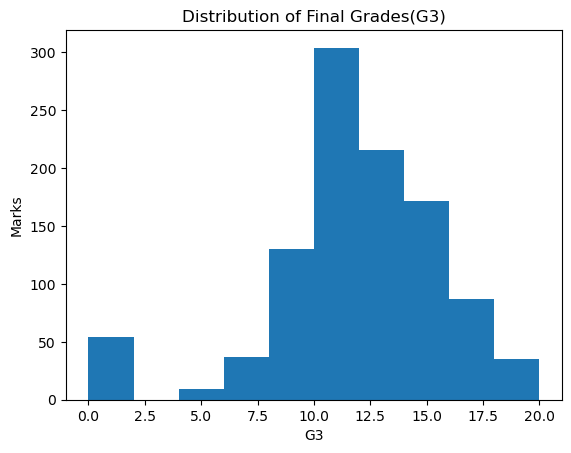

In [20]:
plt.hist(df['G3'])
plt.title("Distribution of Final Grades(G3)")
plt.xlabel('G3')
plt.ylabel('Marks')
plt.show()

In [36]:
df_corr = df.corr(numeric_only=True)

In [51]:
df_corr

,sex,age,address,Medu,Fedu,traveltime,studytime,failures,schoolsup,famsup,internet,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass
sex,1.000000,-0.038832,-0.011556,0.109387,0.070786,0.042508,-0.239972,0.065543,-0.119411,-0.137696,0.062671,0.074725,0.181603,0.062530,0.275928,0.302623,0.141113,-0.013076,-0.025122,-0.025024,-0.031472,-0.036820
age,-0.038832,1.000000,0.071257,-0.130196,-0.138521,0.049216,-0.007870,0.282364,-0.202824,-0.116904,-0.033229,0.007162,0.002645,0.118510,0.133453,0.098291,-0.029129,0.153196,-0.124121,-0.119475,-0.125282,-0.047183
address,-0.011556,0.071257,1.000000,-0.179720,-0.124303,0.343803,-0.037480,0.061160,-0.023583,-0.011975,-0.194790,0.016801,0.009744,-0.030790,0.064030,0.043391,0.010895,-0.036696,-0.113113,-0.127793,-0.117696,-0.111183
Medu,0.109387,-0.130196,-0.179720,1.000000,0.642063,-0.238181,0.090616,-0.187769,-0.023618,0.143063,0.249728,0.015004,0.001054,0.025614,0.001515,-0.029331,-0.013254,0.059708,0.226101,0.224662,0.201472,0.228394
Fedu,0.070786,-0.138521,-0.124303,0.642063,1.000000,-0.196328,0.033458,-0.191390,0.032450,0.153342,0.170012,0.013066,0.002142,0.030075,-0.000165,0.019524,0.034288,0.040829,0.195898,0.182634,0.159796,0.141303
traveltime,0.042508,0.049216,0.343803,-0.238181,-0.196328,1.000000,-0.081328,0.087177,-0.033940,-0.026117,-0.169485,-0.012578,-0.007403,0.049740,0.109423,0.084292,-0.029002,-0.022669,-0.121053,-0.140163,-0.102627,-0.121591
studytime,-0.239972,-0.007870,-0.037480,0.090616,0.033458,-0.081328,1.000000,-0.152024,0.070598,0.143858,0.049695,0.012324,-0.094429,-0.072941,-0.159665,-0.229073,-0.063044,-0.075594,0.211314,0.183167,0.161629,0.162741
failures,0.065543,0.282364,0.061160,-0.187769,-0.191390,0.087177,-0.152024,1.000000,0.002483,-0.027574,-0.074263,-0.053676,0.102679,0.074683,0.116336,0.107432,0.048311,0.099998,-0.374175,-0.377172,-0.383145,-0.229654
schoolsup,-0.119411,-0.202824,-0.023583,-0.023618,0.032450,-0.033940,0.070598,0.002483,1.000000,0.086945,-0.016827,-0.007634,-0.026126,-0.051227,-0.025852,-0.093517,0.000785,-0.009104,-0.136877,-0.088393,-0.079346,-0.164256
famsup,-0.137696,-0.116904,-0.011975,0.143063,0.153342,-0.026117,0.143858,-0.027574,0.086945,1.000000,0.082522,0.002261,0.006227,0.005252,-0.022275,-0.073596,0.022668,0.031267,-0.013655,-0.004521,0.013313,-0.014122


In [37]:
print(df_corr['G3'].sort_values(ascending=False))

G3            1.000000
G2            0.910743
G1            0.809142
Medu          0.201472
studytime     0.161629
Fedu          0.159796
internet      0.107064
famrel        0.054461
famsup        0.013313
sex          -0.031472
absences     -0.045671
freetime     -0.064890
schoolsup    -0.079346
health       -0.080079
goout        -0.097877
traveltime   -0.102627
Walc         -0.115740
address      -0.117696
age          -0.125282
Dalc         -0.129642
failures     -0.383145
Name: G3, dtype: float64


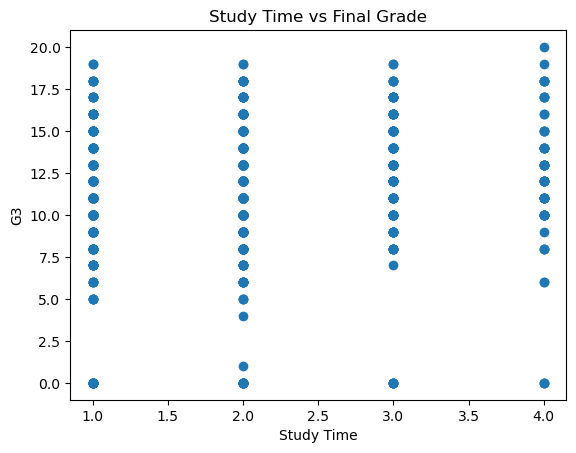

In [38]:
plt.scatter(df['studytime'],df['G3'])
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("G3")
plt.show()

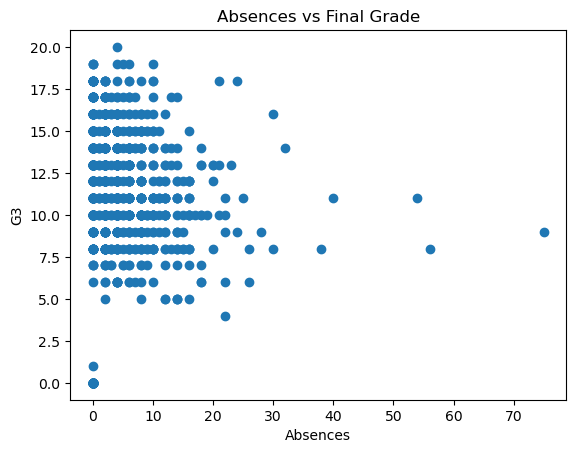

In [39]:
plt.scatter(df['absences'],df['G3'])
plt.title("Absences vs Final Grade")
plt.xlabel("Absences")
plt.ylabel("G3")
plt.show()

In [25]:
#plt.scatter(df['failures'], df['G3'])
#plt.title("Failures vs Final Grade")
#plt.xlabel("Failures")
#plt.ylabel("G3")
#plt.show()

# M3: Probability

In [40]:
df['G3'].max(),df['G3'].min(),df['G3'].median()

(20, 0, 11.0)

In [41]:
df['G3'].unique()

array([ 6, 10, 15, 11, 19,  9, 12, 14, 16,  5,  8, 17, 18, 13, 20,  7,  0,
        4,  1], dtype=int64)

In [42]:
sorted(df['G3'].unique())

[0, 1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

In [43]:
# Step 1: Create Pass column (G3 >= 15)
df['pass'] = df['G3'] >= 14

In [44]:
df['pass'].unique()

array([False,  True])

In [ ]:
#len(df[~df['pass']]),len(df[df['pass']]) also works for count true and false

In [49]:
# Step 2: Basic Probability
print("Total Students:", len(df))
print("Passed Students:", len(df[df['pass']]))
print("Probability of Pass:",round(len(df[df['pass'] == True])/len(df),2))

Total Students: 1044
Passed Students: 294
Probability of Pass: 0.28


In [51]:
sorted(df['studytime'].unique())

[1, 2, 3, 4]

In [52]:
# Step 3: Conditional Probability (high Study Time)
# High study time
high = df[df['studytime'] >= 3]
high_pass = high[high['pass']== True]
len(high),len(high_pass)

(224, 94)

In [53]:
#pd.set_option('display.max_columns', None)
#high['studytime']
high

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject,pass
3,GP,0,15,0,GT3,T,4,2,health,services,home,mother,1,3,0,0,1,yes,yes,yes,yes,1,yes,3,2,2,1,1,5,2,15,14,15,Math,True
11,GP,0,15,0,GT3,T,2,1,services,other,reputation,father,3,3,0,0,1,no,yes,yes,yes,1,no,5,2,2,1,1,4,4,10,12,12,Math,False
14,GP,1,15,0,GT3,A,2,2,other,other,home,other,1,3,0,0,1,no,no,yes,yes,1,yes,4,5,2,1,1,3,0,14,16,16,Math,True
16,GP,0,16,0,GT3,T,4,4,services,services,reputation,mother,1,3,0,0,1,yes,yes,yes,yes,1,no,3,2,3,1,2,2,6,13,14,14,Math,True
24,GP,0,15,1,GT3,T,2,4,services,health,course,mother,1,3,0,1,1,yes,yes,yes,yes,1,no,4,3,2,1,1,5,2,10,9,8,Math,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023,MS,0,17,0,GT3,T,2,2,other,at_home,home,mother,1,3,0,0,0,no,yes,yes,yes,0,yes,3,4,3,1,1,3,8,10,11,12,Portuguese,False
1025,MS,0,18,1,LE3,T,4,4,other,other,reputation,mother,2,3,0,0,0,no,no,yes,yes,1,no,5,4,4,1,1,1,0,15,17,17,Portuguese,True
1026,MS,0,18,1,GT3,T,1,1,other,other,home,mother,4,3,0,0,0,no,no,yes,yes,1,no,4,3,2,1,2,4,4,10,11,12,Portuguese,False
1036,MS,0,18,1,GT3,T,2,2,at_home,other,other,mother,2,3,0,0,0,no,no,yes,yes,0,no,5,3,3,1,3,4,0,14,17,15,Portuguese,True


In [54]:
high_pass

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject,pass
3,GP,0,15,0,GT3,T,4,2,health,services,home,mother,1,3,0,0,1,yes,yes,yes,yes,1,yes,3,2,2,1,1,5,2,15,14,15,Math,True
14,GP,1,15,0,GT3,A,2,2,other,other,home,other,1,3,0,0,1,no,no,yes,yes,1,yes,4,5,2,1,1,3,0,14,16,16,Math,True
16,GP,0,16,0,GT3,T,4,4,services,services,reputation,mother,1,3,0,0,1,yes,yes,yes,yes,1,no,3,2,3,1,2,2,6,13,14,14,Math,True
36,GP,1,15,0,LE3,T,4,3,teacher,services,home,mother,1,3,0,0,1,no,yes,yes,yes,1,no,5,4,3,1,1,4,2,15,16,18,Math,True
37,GP,1,16,1,GT3,A,4,4,other,teacher,reputation,mother,2,3,0,0,1,no,yes,yes,yes,1,yes,2,4,3,1,1,5,7,15,16,15,Math,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1006,MS,0,18,1,GT3,T,2,2,services,other,home,mother,2,3,0,0,0,no,no,yes,yes,1,yes,4,2,1,1,1,4,5,14,14,15,Portuguese,True
1012,MS,0,18,0,LE3,T,1,1,at_home,services,course,father,2,3,0,0,0,no,no,yes,yes,1,no,5,3,2,1,1,4,0,19,17,18,Portuguese,True
1018,MS,1,18,0,LE3,T,4,4,teacher,services,other,mother,2,3,0,0,0,no,no,yes,yes,1,yes,4,2,2,2,2,5,0,15,16,16,Portuguese,True
1025,MS,0,18,1,LE3,T,4,4,other,other,reputation,mother,2,3,0,0,0,no,no,yes,yes,1,no,5,4,4,1,1,1,0,15,17,17,Portuguese,True


In [55]:
print("P(Pass | High Study):",round(len(high_pass)/len(high),2)) # P(A/B)

P(Pass | High Study): 0.42


In [177]:
#high = high['pass'] == True comman mistake
#high = high[high['pass']== True]

In [35]:
#print("P(Pass | High Study):",round(len(high_pass)/len(df),2)) # P(A interesction B)

# M4 – Statistical Inference (t-test)

# 👉 We compare two groups:

Group 1 → Male students
Group 2 → Female students



 # Is difference in G3 real?

In [57]:
# ===============================
# M4: Statistical Inference (t-test)
# ===============================

from scipy.stats import ttest_ind

# Step 1: Create groups
male = df[df['sex'] == 1]['G3']
female = df[df['sex'] == 0]['G3']

# Step 2: Perform t-test
t_stat, p_value = ttest_ind(male, female)

# Step 3: Print results
print("T-statistic:", round(t_stat, 2))
print("P-value:", round(p_value, 4))

# Step 4: Decision
if p_value < 0.05:
    print("Significant difference between male and female performance")
else:
    print("No significant difference")

T-statistic: -1.02
P-value: 0.3097
No significant difference


# M4: Comparison (Without t-test)

In [58]:
# 1. Male vs Female
print("Average Marks by Gender:")
print(df.groupby('sex')['G3'].mean())

# -------------------------------

# 2. Study Time vs Marks
print("\nAverage Marks by Study Time:")
print(df.groupby('studytime')['G3'].mean())


# -------------------------------

# 3. Subject Comparison
print("\nAverage Marks by Subject:")
print(df.groupby('subject')['G3'].mean())

Average Marks by Gender:
sex
0    11.448393
1    11.203091
Name: G3, dtype: float64

Average Marks by Study Time:
studytime
1    10.580442
2    11.335984
3    12.493827
4    12.274194
Name: G3, dtype: float64

Average Marks by Subject:
subject
Math          10.415190
Portuguese    11.906009
Name: G3, dtype: float64


 # M5: Regression (Predict Student Marks)

In [69]:
# ===============================
# M5: Regression Model
# ===============================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Step 1: Select features
X = df[['studytime', 'failures', 'absences']]
y = df['G3']

# Step 2: Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Step 3: Create model
model = LinearRegression()

# Step 4: Train model
model.fit(X_train, y_train)

# Step 5: Predict
y_pred = model.predict(X_test)

# Step 6: Evaluation
print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
print("R2 Score:", round(r2_score(y_test, y_pred), 2))

MAE: 2.57
R2 Score: 0.12


In [70]:
# ===============================
# M5: Regression using studytime
# ===============================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Step 1: Select ONE feature
X = df[['studytime']]   # only one feature
y = df['G3']

# Step 2: Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Step 3: Create model
model = LinearRegression()

# Step 4: Train model
model.fit(X_train, y_train)

# Step 5: Predict
y_pred = model.predict(X_test)

# Step 6: Evaluation
print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
print("R2 Score:", round(r2_score(y_test, y_pred), 2))

MAE: 2.94
R2 Score: 0.01


In [71]:
model.predict([[3]])

array([12.17338189])

In [72]:
import warnings
warnings.filterwarnings("ignore")
model.predict([[3]])

array([12.17338189])

In [73]:
import pandas as pd

new_data = pd.DataFrame([[3]], columns=['studytime'])

print("Predicted G3:", model.predict(new_data)[0])

Predicted G3: 12.173381890207978


In [74]:
# ===============================
# M5: Regression using studytime
# ===============================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Step 1: Select ONE feature
X = df[['studytime','G2','G1','Medu']]   # only one feature
y = df['G3']

# Step 2: Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Step 3: Create model
model = LinearRegression()

# Step 4: Train model
model.fit(X_train, y_train)

# Step 5: Predict
y_pred = model.predict(X_test)

# Step 6: Evaluation
print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
print("R2 Score:", round(r2_score(y_test, y_pred), 2))

MAE: 0.96
R2 Score: 0.83


 # M6: Storytelling (Explain Results)

In [75]:
df.groupby('studytime')['G3'].mean()

studytime
1    10.580442
2    11.335984
3    12.493827
4    12.274194
Name: G3, dtype: float64

In [197]:
df.groupby('failures')['G3'].mean()

failures
0    12.054588
1     8.425000
2     7.484848
3     6.800000
Name: G3, dtype: float64

In [79]:
df.groupby('abs_group')['G3'].mean()

KeyError: 'abs_group'

In [199]:
df.groupby('subject')['G3'].mean()

subject
Math          10.415190
Portuguese    11.906009
Name: G3, dtype: float64

# Optional: Visualization

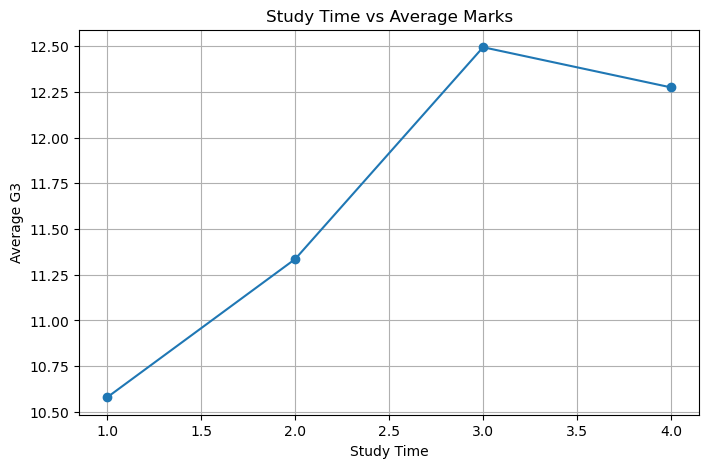

In [201]:
import matplotlib.pyplot as plt

# Calculate average G3 for each studytime
avg_marks = df.groupby('studytime')['G3'].mean()

# Plot line graph
plt.figure(figsize=(8,5))
plt.plot(avg_marks.index, avg_marks.values, marker='o')

# Labels and title
plt.title("Study Time vs Average Marks")
plt.xlabel("Study Time")
plt.ylabel("Average G3")

plt.grid(True)
plt.show()